# Lab 05: OpenAPI and Reproducible Data Ingestion

Last week we aligned scattered observations into a **(grid cell × time window)
spatiotemporal cube**. But where do those observations come from in the first place, and
how? Today we build the **very first piece, ① observation ingestion**, of the closed-loop
digital twin pipeline: an **ingestion script** that sends queries with `requests` to an
**OpenAPI (REST) endpoint** open on the web, parses the responses, and collects them
*reproducibly* with **pagination and caching**.

There is one problem. The build and lab machines have no KMA API key, and the real server
can be slow or go down, so the class would **not be reproducible**. So today we start a
**local mock weather API** inside our own notebook that imitates the response structure of
the KMA public-data OpenAPI exactly, and learn **real HTTP requests** on top of it. The code
transfers unchanged to the real KMA endpoint (confirmed in Section 6).


## Learning Objectives

By the end of this lab you will be able to:

- Decompose an OpenAPI request into **URL + query parameters + authentication key**, and
  read the **status code, headers and body** of the response `requests` returns.
- Parse the **JSON, XML and CSV** serialisations of the same data and confirm they yield
  identical records, and handle the standard response envelope (`resultCode`,
  `totalCount`, `items`).
<!-- - Loop over **pagination** (`pageNo`/`numOfRows`/`totalCount`) to collect **everything**,
  and verify numerically that the collection is complete. -->
<!-- - Build a robust collector with **exponential-backoff retries** against transient failures -->
  <!-- (429/503). -->
- Make ingestion **reproducible** with **caching + checksums + a manifest** (same request →
  same checksum; a re-run uses the cache with no network).
- Build an **M0 persistence baseline** from the ingested observations and validate its
  format.


In [1]:

import os, sys, io, json, time, hashlib, threading, tempfile
import urllib.parse
from http.server import BaseHTTPRequestHandler, HTTPServer
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

import requests

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
rng = np.random.default_rng(0)          # reproducibility: fixed seed

# Today's cache and outputs stay inside this temporary directory (the course repo is untouched).
WORK = tempfile.mkdtemp(prefix="course410_wk05_")
print("working directory:", WORK)
print("python           :", sys.version.split()[0])
print("requests         :", requests.__version__)


working directory: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk05_unts8fzi
python           : 3.11.0
requests         : 2.32.5


---
## 1. What is an OpenAPI? — the anatomy of a request

An **OpenAPI** (here in the broad sense of "a REST API published on the web") is a server
that *returns a structured response when you request data by URL*. The observation APIs of
KMA and the Korean public data portal have exactly this shape. A single request decomposes
into these pieces:

| Piece | Example | Role |
|---|---|---|
| **base URL** | `http://.../api/obs` | which resource of which service |
| **query params** | `?stn=108&tm1=...&numOfRows=10` | *what* you want, and how much |
| **auth key** | `authKey=...` (or `serviceKey`) | *who* is asking |
| **HTTP method** | `GET` | read (GET) / write (POST) |

The server answers with a **status code** and a **body**. The codes you see most often:

| Code | Meaning | What the collector should do |
|---|---|---|
| `200 OK` | success | parse the body |
| `400` | bad request (parameter error) | fix the parameters |
| `401/403` | authentication failed | check the key |
| `429` | too many requests (rate limit) | **wait and retry** |
| `500/503` | server error or overload | **wait and retry** |

**Careful:** The public data portal may return 200 even when authentication fails. The actual error appears in the `resultCode` inside the response body. Therefore, you must check both the HTTP status code and the `resultCode`.

First, with no network involved, let us see how `requests` **assembles a URL** from
parameters.


In [2]:

from requests import Request

# We are not sending anything yet -- just seeing how parameters get encoded into a query string.
demo_base = "http://example.data.go.kr/api/obs"
demo_params = {
    "authKey": "DEMO-KEY-123",
    "stn": 108,                       # station number
    "tm1": "202508010000",           # start time YYYYMMDDHHmm
    "tm2": "202508012300",           # end time
    "dataType": "JSON",
    "pageNo": 1,
    "numOfRows": 10,
}
prepared = Request("GET", demo_base, params=demo_params).prepare()
print("assembled request URL:")
print(" ", prepared.url)
print()
print("-> the dict was encoded as '?key=value&key=value' (spaces and special characters escaped safely).")


assembled request URL:
  http://example.data.go.kr/api/obs?authKey=DEMO-KEY-123&stn=108&tm1=202508010000&tm2=202508012300&dataType=JSON&pageNo=1&numOfRows=10

-> the dict was encoded as '?key=value&key=value' (spaces and special characters escaped safely).


> **Observe:** an OpenAPI request is, in the end, a **base URL plus encoded query
> parameters**. `requests` assembles the dict into a URL query string safely, so we can
> concentrate on *what to ask for* (the parameters). Now we need a server that will actually
> answer such a request — let us start a **local mock weather API** so that it reproduces
> offline too.

---
## 2. Starting a local mock weather API

Why a mock server? Two reasons. (1) **Credential isolation** — the class has to run even
though the build machine has no KMA key. (2) **Reproducibility** — a real server is slow or
occasionally down, so results change every time. So we start a small server with Python's
standard `http.server` inside the notebook that **imitates the response structure** of the
KMA public-data API exactly. That way students learn **real HTTP requests** (real status
codes, real pagination, real rate limits) while the code stays deterministic and green
offline.

The **envelope** the mock API returns follows the public-data-portal standard:

```
{"response": {"header": {"resultCode": "00", "resultMsg": "NORMAL_SERVICE"},
              "body":   {"dataType": "JSON", "pageNo": 1, "numOfRows": 10,
                         "totalCount": 576, "items": {"item": [ ...observations... ]}}}}
```

The observations behind the server are **generated deterministically** (inheriting the
temperature structure of Week 4: an afternoon-peaking diurnal cycle plus a cooler-to-the-north
latitude gradient). 8 stations × 3 days × hourly = **576 records**. Each record is
`stn, tm, lat, lon, ta` (temperature).


In [3]:

# --- The observations behind the mock server (deterministically generated) ---
STN_META = [   # (station number, latitude, longitude) -- approximations of major Korean sites
    (108, 37.57, 126.98), (105, 37.75, 128.89), (112, 37.48, 126.62),
    (133, 36.37, 127.37), (143, 35.87, 128.65), (156, 35.17, 126.89),
    (159, 35.10, 129.03), (184, 33.51, 126.53),
]

def _true_temp(lat, hour, day, noise):
    diurnal  = 4.0 * np.sin(2 * np.pi * (hour - 9) / 24)   # afternoon peak (~15:00)
    lat_grad = -1.8 * (lat - 36.0)                         # cooler further north
    daily    =  0.5 * (day - 1)                            # gentle day-to-day rise
    return 27.0 + diurnal + lat_grad + daily + noise

gen = np.random.default_rng(1)          # seed for data generation (kept apart from the analysis rng)
DATA = []                               # everything the mock server will serve
for (stn, lat, lon) in STN_META:
    for d in range(1, 4):               # 2025-08-01 .. 03
        for h in range(24):
            ta = _true_temp(lat, h, d, float(gen.normal(0, 0.4)))
            DATA.append({"stn": stn, "tm": f"202508{d:02d}{h:02d}00",
                         "lat": round(lat, 4), "lon": round(lon, 4),
                         "ta": round(float(ta), 2)})

MOCK_KEY = "DEMO-KEY-123"               # the auth key the mock server demands
print(f"records behind the mock server: {len(DATA)} "
      f"({len(STN_META)} stations x 3 days x 24 hours)")
print("example:", DATA[0])


records behind the mock server: 576 (8 stations x 3 days x 24 hours)
example: {'stn': 108, 'tm': '202508010000', 'lat': 37.57, 'lon': 126.98, 'ta': 21.48}


In [4]:

# --- Response serialisation builders (JSON / XML / CSV) ---
def _envelope(items, pageNo, numOfRows, total, dtype="JSON",
              code="00", msg="NORMAL_SERVICE"):
    return {"response": {"header": {"resultCode": code, "resultMsg": msg},
            "body": {"dataType": dtype, "pageNo": pageNo, "numOfRows": numOfRows,
                     "totalCount": total, "items": {"item": items}}}}

def _to_xml(items, pageNo, numOfRows, total):
    parts = ['<?xml version="1.0" encoding="UTF-8"?>', "<response>",
             "<header><resultCode>00</resultCode><resultMsg>NORMAL_SERVICE</resultMsg></header>",
             "<body>",
             f"<dataType>XML</dataType><pageNo>{pageNo}</pageNo>"
             f"<numOfRows>{numOfRows}</numOfRows><totalCount>{total}</totalCount>",
             "<items>"]
    for it in items:
        inner = "".join(f"<{k}>{it[k]}</{k}>" for k in ("stn", "tm", "lat", "lon", "ta"))
        parts.append("<item>" + inner + "</item>")
    parts += ["</items>", "</body>", "</response>"]
    return "".join(parts)

def _to_csv(items):
    lines = ["stn,tm,lat,lon,ta"]
    lines += [f"{it['stn']},{it['tm']},{it['lat']},{it['lon']},{it['ta']}" for it in items]
    return "\n".join(lines)

print("serialisation builders ready (JSON/XML/CSV)")


serialisation builders ready (JSON/XML/CSV)


In [5]:

# --- The mock weather API handler ---
class MockKMAHandler(BaseHTTPRequestHandler):
    def log_message(self, *a):          # suppress console logging (headless)
        pass

    def _send(self, code, body, ctype, extra=None):
        b = body.encode() if isinstance(body, str) else body
        self.send_response(code)
        self.send_header("Content-Type", ctype)
        self.send_header("Content-Length", str(len(b)))
        for k, v in (extra or {}).items():
            self.send_header(k, v)
        self.end_headers()
        self.wfile.write(b)

    def do_GET(self):
        u = urllib.parse.urlparse(self.path)
        qs = urllib.parse.parse_qs(u.query)
        def q1(k, d=None):
            return qs.get(k, [d])[0]

        # The observation endpoint (any other path -> 404)
        if u.path != "/api/obs":
            return self._send(404, "not found", "text/plain")

        # Auth: a wrong key gives HTTP 200 + resultCode='30' in the body (the data.go.kr way)
        if q1("authKey") != MOCK_KEY:
            env = _envelope([], 1, 0, 0, code="30",
                            msg="SERVICE_KEY_IS_NOT_REGISTERED_ERROR")
            return self._send(200, json.dumps(env), "application/json")

        # Server-side filters: station (stn) and time range (tm1..tm2)
        stn = q1("stn")
        tm1, tm2 = q1("tm1", "000000000000"), q1("tm2", "999999999999")
        rows = [r for r in DATA
                if (stn is None or str(r["stn"]) == str(stn))
                and tm1 <= r["tm"] <= tm2]
        rows.sort(key=lambda r: (r["stn"], r["tm"]))
        total = len(rows)

        # Pagination
        pageNo = int(q1("pageNo", "1"))
        numOfRows = int(q1("numOfRows", "10"))
        page = rows[(pageNo - 1) * numOfRows: pageNo * numOfRows]

        dtype = (q1("dataType", "JSON") or "JSON").upper()
        if dtype == "XML":
            return self._send(200, _to_xml(page, pageNo, numOfRows, total),
                              "application/xml")
        if dtype == "CSV":
            return self._send(200, _to_csv(page), "text/csv")
        return self._send(200, json.dumps(_envelope(page, pageNo, numOfRows, total)),
                          "application/json")

print("handler defined.")


handler defined.


In [6]:

# Port 0 -> the OS assigns a free port. Served on a daemon thread (cleaned up when the notebook exits).
httpd = HTTPServer(("127.0.0.1", 0), MockKMAHandler)
PORT = httpd.server_address[1]
BASE = f"http://127.0.0.1:{PORT}"
threading.Thread(target=httpd.serve_forever, daemon=True).start()

# Readiness check: a health request
r = requests.get(f"{BASE}/api/obs",
                 params={"authKey": MOCK_KEY, "numOfRows": 1}, timeout=5)
print(f"mock weather API running: {BASE}   (status code {r.status_code})")


mock weather API running: http://127.0.0.1:65141   (status code 200)


Now let's send our first real request (to the local mock server) and look closely at the answer. First, we will use a wrong key on purpose. On the public data portal, a bad key still gives HTTP 200 (OK). The error is shown in the body, in a field called `resultCode`.


In [7]:
# bad 
print(f'{BASE}/api/obs?stn=108&numOfRows=3')

# ok 
print(f'{BASE}/api/obs?authKey=DEMO-KEY-123&stn=108&numOfRows=3')

http://127.0.0.1:65141/api/obs?stn=108&numOfRows=3
http://127.0.0.1:65141/api/obs?authKey=DEMO-KEY-123&stn=108&numOfRows=3


In [8]:

# (1) Request with no key -> HTTP 200, but resultCode='30' (authentication failed)
bad = requests.get(f"{BASE}/api/obs", params={"stn": 108, "numOfRows": 3}, timeout=5)
head_bad = bad.json()["response"]["header"]
print(f"[no key] HTTP {bad.status_code}  resultCode={head_bad['resultCode']} "
      f"({head_bad['resultMsg']})")

# (2) Request with the correct key -> resultCode='00'
ok = requests.get(f"{BASE}/api/obs",
                  params={"authKey": MOCK_KEY, "stn": 108, "numOfRows": 3},
                  timeout=5)
env = ok.json()
head_ok = env["response"]["header"]
body_ok = env["response"]["body"]
print(f"[with key] HTTP {ok.status_code}  resultCode={head_ok['resultCode']} "
      f"({head_ok['resultMsg']})")
print(f"response header Content-Type: {ok.headers['Content-Type']}")
print(f"body: totalCount={body_ok['totalCount']}, items on this page={len(body_ok['items']['item'])}")
print("first record:", body_ok["items"]["item"][0])

assert bad.status_code == 200 and head_bad["resultCode"] == "30"
assert ok.status_code == 200 and head_ok["resultCode"] == "00"


[no key] HTTP 200  resultCode=30 (SERVICE_KEY_IS_NOT_REGISTERED_ERROR)
[with key] HTTP 200  resultCode=00 (NORMAL_SERVICE)
response header Content-Type: application/json
body: totalCount=72, items on this page=3
first record: {'stn': 108, 'tm': '202508010000', 'lat': 37.57, 'lon': 126.98, 'ta': 21.48}


> **Observe:** both requests returned **HTTP 200**, yet the authentication failure showed
> up only as `resultCode='30'` in the body. **A status code of 200 does not mean success** —
> with public-data-portal-style APIs you must always check `resultCode` as well. With the
> correct key we got `resultCode='00'` plus the standard envelope carrying the observations
> (`totalCount`, `items.item`). Let us now **parse** that envelope into a table.

---
## 3. Parsing responses — JSON, XML and CSV are the same data in different clothes

Public-data-portal APIs usually let you pick **JSON or XML** with a `dataType` parameter
(some also offer CSV). All three are merely **different serialisations of the same
observations**. Our mock server supports all three, so let us fetch **one day (24 hours)** of
station 108 in each format, parse each one, and confirm numerically that the **records are
identical**.


In [9]:

common = {"authKey": MOCK_KEY, "stn": 108,
          "tm1": "202508010000", "tm2": "202508012300", "numOfRows": 24}

# (a) JSON
j = requests.get(f"{BASE}/api/obs", params=dict(common, dataType="JSON")).json()
df_json = pd.DataFrame(j["response"]["body"]["items"]["item"])

# (b) XML -- parsed with ElementTree
xml_text = requests.get(f"{BASE}/api/obs", params=dict(common, dataType="XML")).text
root = ET.fromstring(xml_text)
recs = [{c.tag: c.text for c in item} for item in root.find("body/items")]
df_xml = pd.DataFrame(recs)

# (c) CSV -- parsed directly by pandas
csv_text = requests.get(f"{BASE}/api/obs", params=dict(common, dataType="CSV")).text
df_csv = pd.read_csv(io.StringIO(csv_text))

print("JSON parsed:", df_json.shape, "| XML parsed:", df_xml.shape, "| CSV parsed:", df_csv.shape)
df_json.head(3)


JSON parsed: (24, 5) | XML parsed: (24, 5) | CSV parsed: (24, 5)


,stn,tm,lat,lon,ta
0,108,202508010000,37.57,126.98,21.48
1,108,202508010100,37.57,126.98,21.04
2,108,202508010200,37.57,126.98,20.44


In [10]:

# Verify the three parsers produced the same observations -- cast numeric columns to float and compare.
def norm(df):
    d = df.copy()
    d["stn"] = d["stn"].astype(int)
    d["ta"]  = d["ta"].astype(float)
    d["lat"] = d["lat"].astype(float)
    return d.sort_values(["stn", "tm"]).reset_index(drop=True)

a, b, c = norm(df_json), norm(df_xml), norm(df_csv)
same_rows = (len(a) == len(b) == len(c) == 24)
max_ta_diff = max(float((a["ta"] - b["ta"]).abs().max()),
                  float((a["ta"] - c["ta"]).abs().max()))
print(f"same record count across the three formats (=24): {same_rows}")
print(f"max absolute difference in temperature (ta), JSON vs XML vs CSV: {max_ta_diff:.2e}")
assert same_rows and max_ta_diff < 1e-9
print("-> JSON, XML and CSV are just different serialisations of the same data; parsing gives the same result.")


same record count across the three formats (=24): True
max absolute difference in temperature (ta), JSON vs XML vs CSV: 0.00e+00
-> JSON, XML and CSV are just different serialisations of the same data; parsing gives the same result.


In [11]:
a

,stn,tm,lat,lon,ta
0,108,202508010000,37.57,126.98,21.48
1,108,202508010100,37.57,126.98,21.04
2,108,202508010200,37.57,126.98,20.44
3,108,202508010300,37.57,126.98,19.65
4,108,202508010400,37.57,126.98,20.67
5,108,202508010500,37.57,126.98,20.89
6,108,202508010600,37.57,126.98,21.13
7,108,202508010700,37.57,126.98,22.41
8,108,202508010800,37.57,126.98,23.28
9,108,202508010900,37.57,126.98,24.29


hour of the highest ingested temperature: 15:00 (planted peak ~ 15:00)


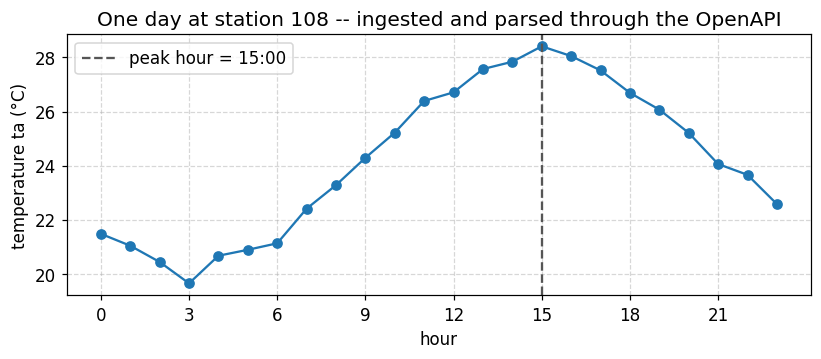

In [12]:

# Check the diurnal cycle in the parsed day -- is the afternoon peak we planted visible?
d = a.copy()
d["hour"] = d["tm"].str[8:10].astype(int)
peak = int(d.loc[d["ta"].idxmax(), "hour"])

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.plot(d["hour"], d["ta"], "o-", color="#1f77b4")
ax.axvline(peak, ls="--", color="#555", label=f"peak hour = {peak}:00")
ax.set_xlabel("hour"); ax.set_ylabel("temperature ta (°C)")
ax.set_title("One day at station 108 -- ingested and parsed through the OpenAPI")
ax.set_xticks(range(0, 24, 3)); ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()
print(f"hour of the highest ingested temperature: {peak}:00 (planted peak ~ 15:00)")


> **Observe:** fetching the same observations as JSON, XML and CSV and parsing each gave
> **exactly the same** record count and the same temperatures to within $10^{-9}$ — the
> serialisation format is *packaging for transport*, not the data. The ingested and parsed
> day even recovered the planted **afternoon peak** (≈15:00). But so far we have seen only
> one page of 24 rows — getting all 576 rows needs **pagination**.

---
## 4. Pagination — `pageNo` / `numOfRows` / `totalCount`

An API will not give you **all** the rows in one request. To limit its own load it caps the
rows per page (`numOfRows`), and the client fetches repeatedly with an increasing `pageNo`
and concatenates. The response's `totalCount` tells you when to stop:

$$\text{total pages} = \left\lceil \frac{\texttt{totalCount}}{\texttt{numOfRows}} \right\rceil$$

**Assume one request is everything and you silently lose data.** Let us write an ingestion
function that walks the pages until it reaches `totalCount`.


In [13]:

def fetch_all(base_params, page_size=100, verbose=True):
    # Increase pageNo until totalCount is reached, collecting everything.
    rows, page, total = [], 1, None
    history = []                        # a record of (page, rows on this page, cumulative)
    while True:
        p = dict(base_params, authKey=MOCK_KEY, dataType="JSON",
                 pageNo=page, numOfRows=page_size)
        env = requests.get(f"{BASE}/api/obs", params=p, timeout=5).json()
        body = env["response"]["body"]
        assert env["response"]["header"]["resultCode"] == "00"
        total = body["totalCount"]
        items = body["items"]["item"]
        rows += items
        history.append((page, len(items), len(rows)))
        if verbose:
            print(f"  page {page}: +{len(items):>3} rows  cumulative {len(rows):>3}/{total}")
        if len(rows) >= total or not items:
            break
        page += 1
    return rows, total, history

print("ingesting all observations (page size 100):")
all_rows, total, hist = fetch_all({}, page_size=100)


ingesting all observations (page size 100):
  page 1: +100 rows  cumulative 100/576
  page 2: +100 rows  cumulative 200/576
  page 3: +100 rows  cumulative 300/576
  page 4: +100 rows  cumulative 400/576
  page 5: +100 rows  cumulative 500/576
  page 6: + 76 rows  cumulative 576/576


In [14]:

import math
n_pages = len(hist)
expected_pages = math.ceil(total / 100)
ids = {(r["stn"], r["tm"]) for r in all_rows}     # the unique (station, time) pairs, no duplicates

print(f"rows collected    : {len(all_rows)}   (totalCount={total})")
print(f"unique (stn,tm)   : {len(ids)}   (no duplicates: {len(ids) == len(all_rows)})")
print(f"pages             : {n_pages}   (expected ceil({total}/100)={expected_pages})")
assert len(all_rows) == total == 576, "the collection is not complete"
assert len(ids) == len(all_rows), "there are duplicates or gaps between pages"
assert n_pages == expected_pages
print("-> pagination collected all 576 rows completely, with no duplicates and no gaps.")


rows collected    : 576   (totalCount=576)
unique (stn,tm)   : 576   (no duplicates: True)
pages             : 6   (expected ceil(576/100)=6)
-> pagination collected all 576 rows completely, with no duplicates and no gaps.


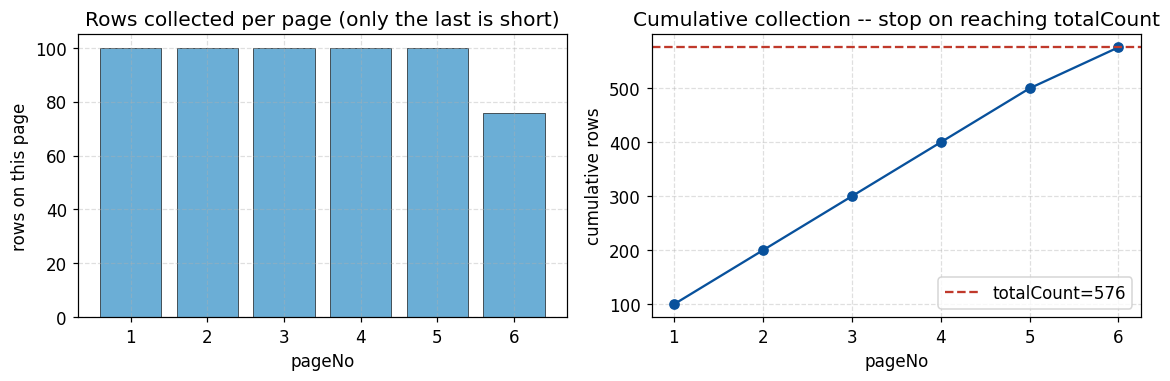

In [15]:

# The per-page collection as a figure -- the last page is short because it holds only the remainder.
pages = [h[0] for h in hist]; per = [h[1] for h in hist]; cum = [h[2] for h in hist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.6, 3.6))
ax1.bar(pages, per, color="#6baed6", edgecolor="k", linewidth=0.4)
ax1.set_xlabel("pageNo"); ax1.set_ylabel("rows on this page")
ax1.set_title("Rows collected per page (only the last is short)")
ax1.grid(True, ls="--", alpha=0.4)

ax2.plot(pages, cum, "o-", color="#08519c")
ax2.axhline(total, ls="--", color="#c0392b", label=f"totalCount={total}")
ax2.set_xlabel("pageNo"); ax2.set_ylabel("cumulative rows")
ax2.set_title("Cumulative collection -- stop on reaching totalCount")
ax2.grid(True, ls="--", alpha=0.4); ax2.legend()
plt.tight_layout()


> **Observe:** since the server gives at most 100 rows per page, it takes **6 pages**
> (⌈576/100⌉) to gather everything up to `totalCount=576`. The last page is short, holding
> only the remaining 76 rows. The number of unique `(stn,tm)` pairs equalled the number of
> collected rows, confirming **no duplicates and no gaps** — and showing why the assumption
> "one request = everything" is dangerous. Next we make sure that re-running the same
> request always gives **the same result**.

---
## 5. Reproducible ingestion — cache · checksum · manifest

**Reproducibility** is what makes an ingestion trustworthy. Being reproducible means: repeat the same request and you get the **same raw bytes**, and you can
**prove** it. We achieve that with three things:

1. **A cache** — build a key from the request parameters and store the raw response on
   disk. A re-run reads from the cache with no network (fast, and deterministic regardless
   of the server's state).
2. **A checksum** — the SHA-256 of the raw bytes. Same request → same checksum means "the
   same data".
3. **A manifest** — a **provenance record** listing (parameters, time, source, row count, checksum).
   It lets someone else reproduce and verify your ingestion exactly.


In [16]:

# ---------------------------------------------------------------
# 1) Cache folder: every raw response is stored here
# ---------------------------------------------------------------
CACHE = os.path.join(WORK, "cache")
os.makedirs(CACHE, exist_ok=True)

MANIFEST = []          # provenance record: one entry per ingestion


def drop_key(params):
    # Remove the auth key -- it must never reach a file name or the manifest.
    return {k: v for k, v in params.items() if k != "authKey"}


# ---------------------------------------------------------------
# 2) Cache key: same request -> same file name
# ---------------------------------------------------------------
def cache_key(params):
    # Sort the parameters so their order does not matter, then hash.
    query = urllib.parse.urlencode(sorted(drop_key(params).items()))
    return hashlib.sha256(query.encode()).hexdigest()[:16]


# ---------------------------------------------------------------
# 3) Fetch: read the cache if present, otherwise ask the server
# ---------------------------------------------------------------
def fetch_reproducible(params):
    key = cache_key(params)
    path = os.path.join(CACHE, key + ".bin")

    if os.path.exists(path):                          # (a) cache hit -> no network
        with open(path, "rb") as fh:
            raw = fh.read()
        source = "cache"
    else:                                             # (b) cache miss -> request, then save
        r = requests.get(f"{BASE}/api/obs",
                         params=dict(params, authKey=MOCK_KEY), timeout=5)
        r.raise_for_status()                          # never cache an error response
        raw = r.content                               # the raw bytes, exactly as received
        with open(path, "wb") as fh:
            fh.write(raw)
        source = "network"

    checksum = hashlib.sha256(raw).hexdigest()        # fingerprint of the raw bytes
    nrows = len(json.loads(raw)["response"]["body"]["items"]["item"])

    MANIFEST.append({
        "key":        key,
        "params":     drop_key(params),
        "fetched_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),   # UTC
        "source":     source,
        "nrows":      nrows,
        "sha256":     checksum[:12],
    })
    return raw, checksum, source


# ---------------------------------------------------------------
# 4) Demo: the same request twice
# ---------------------------------------------------------------
p = {"stn": 108, "tm1": "202508010000", "tm2": "202508012300",
     "dataType": "JSON", "numOfRows": 24}

raw1, sum1, src1 = fetch_reproducible(p)          # 1st call: network
raw2, sum2, src2 = fetch_reproducible(p)          # 2nd call: cache

print(f"1st: source={src1:<7}  sha256={sum1[:12]}...")
print(f"2nd: source={src2:<7}  sha256={sum2[:12]}...")

assert src1 == "network" and src2 == "cache"
assert sum1 == sum2, "the same request must give the same checksum (reproducibility)"
print("-> same request -> same checksum. The second call was reproduced from cache, with no network.")

1st: source=network  sha256=6cf55ba3be95...
2nd: source=cache    sha256=6cf55ba3be95...
-> same request -> same checksum. The second call was reproduced from cache, with no network.


In [17]:

# Ingest a few more stations to fill the manifest -- this is the 'provenance record'.
for stn in (105, 133, 159):
    fetch_reproducible({"stn": stn, "tm1": "202508010000", "tm2": "202508012300",
                        "dataType": "JSON", "numOfRows": 24})

man = pd.DataFrame(MANIFEST)
print("ingestion manifest (provenance record for reproduction and verification):")
print(man[["key", "source", "nrows", "sha256"]].to_string(index=False))

man_path = os.path.join(WORK, "ingest_manifest.json")
json.dump(MANIFEST, open(man_path, "w"), ensure_ascii=False, indent=2)
print(f"\nmanifest saved: {man_path}")
print("-> leave the parameters and checksums behind and someone else can reproduce and cross-check your ingestion.")


ingestion manifest (provenance record for reproduction and verification):
             key  source  nrows       sha256
bc7df070d6e94b47 network     24 6cf55ba3be95
bc7df070d6e94b47   cache     24 6cf55ba3be95
8c55c01f1c9ca7c7 network     24 a1c37f3fd974
4c62dfe506250ba7 network     24 4725b5b3b204
d9dfb18f58469cc1 network     24 20d7f0e54cdd

manifest saved: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk05_unts8fzi/ingest_manifest.json
-> leave the parameters and checksums behind and someone else can reproduce and cross-check your ingestion.


> **Observe:** the second request with the same parameters came **from the cache, with no
> network**, and the SHA-256 of the raw bytes **matched exactly** — proof of "same request →
> same data". The manifest records the (parameters, time, source, row count, checksum) of each
> ingestion, becoming a **reproducible provenance record**. Thanks to the cache, re-running
> the notebook is deterministic regardless of the server's state.
>
> **Where to keep the manifest:** this notebook writes it to a temporary folder (`WORK`) so
> the course repo stays untouched — that folder can be wiped by the system. In your own
> assignments and research, save the manifest **next to the data inside your project**
> (e.g. `data/ingest_manifest.json`) and commit it to git with your code. Only then is it a
> lasting record.
>
> Now let us see how to connect the collector we have built to the **real KMA API**.

---
## 6. On to the real KMA API — the code stays; only the URL, key and parameters change

Everything so far (assembling parameters → requesting → checking the response → parsing →
pagination → caching) transfers **unchanged to the real KMA API**. What changes is the
**base URL**, the **authentication key**, and the **query parameters** of the service you
call. For example, KMA's **ultra-short-term nowcast** (`getUltraSrtNcst` — the latest
observed values on KMA's 5 km forecast grid) on the **public data portal** (`data.go.kr`):

```
https://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtNcst
  ?serviceKey=<issued key>&dataType=JSON&numOfRows=10&pageNo=1
  &base_date=20250801&base_time=0600&nx=55&ny=127
```

| Parameter | Meaning |
|---|---|
| `serviceKey` | your data.go.kr key (our mock server called it `authKey`) |
| `base_date`, `base_time` | the observation time (`YYYYMMDD`, `HH00`) |
| `nx`, `ny` | a cell of KMA's 5 km forecast grid (**not** latitude/longitude) |
| `numOfRows`, `pageNo` | pagination, exactly as in Section 4 |

The response uses the same `response → header / body → items → item` envelope as our mock
server, and — just like it — reports errors as **HTTP 200 + `resultCode`**. Each item is one
variable (`category`: `T1H` temperature, `REH` humidity, `RN1` 1-hour rain, `WSD` wind
speed, …) with its value in `obsrValue`. This service only keeps **recent** data (about the
last day), so the cell below asks for the previous full hour rather than a fixed date.

**Getting a key.** Sign up at the [public data portal](https://www.data.go.kr), search for
*기상청_단기예보 조회서비스* (`VilageFcstInfoService_2.0`), and click **활용신청** (apply for
use). Approval is usually automatic; the key appears under *마이페이지 → 개발계정*. The
portal shows an **Encoding** and a **Decoding** key — use the **Decoding** key, because
`requests` URL-encodes parameters itself (the Encoding key would be encoded twice and
rejected).

**Where to put the key — a `.env` file.** Never type the key into the notebook (it leaks the
moment you share or push it). Instead create a file named `.env` in your project folder:

```
KMA_API_KEY=your-decoding-key
```

No quotes, no spaces around `=`. The cell below reads it with `python-dotenv`'s
`load_dotenv()`, which searches the current folder and its parents. **Add `.env` to your
`.gitignore`** so it can never be committed.

**The build and lab machines have no key**, so the real-call cell below runs **only when**
`KMA_API_KEY` is present; without it we simply carry on with the observations gathered from
the mock server — this is STYLE_SPEC's **network/credential isolation**.

In [18]:
# The real call happens only inside the environment-variable guard -- green even on a key-less build machine.
try:
    from dotenv import load_dotenv               # pip install python-dotenv
    load_dotenv()                                # reads KMA_API_KEY=... from a .env file, if any
except ImportError:
    pass                                         # no python-dotenv -> use the shell environment only

KMA_KEY = os.environ.get("KMA_API_KEY")          # your data.go.kr (Decoding) key

if KMA_KEY:
    # Nowcast data for an hour is ready ~40 min after it, so ask for the previous full hour (KST).
    t = pd.Timestamp.now(tz="Asia/Seoul") - pd.Timedelta(hours=1)

    kma_url = "https://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtNcst"
    params = {
        "serviceKey": KMA_KEY,
        "dataType":   "JSON",
        "numOfRows":  10,
        "pageNo":     1,
        "base_date":  t.strftime("%Y%m%d"),
        "base_time":  t.strftime("%H00"),
        "nx": 55, "ny": 127,                      # forecast-grid cell, not lat/lon
    }
    r = requests.get(kma_url, params=params, timeout=10)

    # Never print r.url or use r.raise_for_status(): both would show the key.
    try:
        env = r.json()["response"]
    except ValueError:                            # a key error may come back as XML, not JSON
        raise RuntimeError(f"KMA API HTTP {r.status_code}: {r.text[:200]}")
    head = env["header"]
    assert head["resultCode"] == "00", f"resultCode={head['resultCode']} ({head['resultMsg']})"

    real = pd.DataFrame(env["body"]["items"]["item"])
    print(f"real KMA API response: {len(real)} rows  (HTTP {r.status_code}, "
          f"{params['base_date']} {params['base_time']} KST)")
    print(real[["category", "obsrValue"]].to_string(index=False))   # T1H = temperature, ...
    print("(Display only -- the M0 baseline below still uses the 576 mock observations from Section 4.)")
else:
    print("no KMA_API_KEY -> build isolation mode.")
    print("Continuing the M0 pipeline with the 576 rows ingested from the local mock API.")
    print("(Put your data.go.kr key in .env as KMA_API_KEY=... and this branch makes the real call.)")


no KMA_API_KEY -> build isolation mode.
Continuing the M0 pipeline with the 576 rows ingested from the local mock API.
(Put your data.go.kr key in .env as KMA_API_KEY=... and this branch makes the real call.)


> **Observe:** the real KMA call and the mock-server call have **the same code shape** —
> build `params`, `requests.get`, check the response, unwrap `response → body → items`. Only
> the URL, the key and the service's own parameters differ. Wrapped in an environment-variable guard, the
> key-less build machine skips the real call and carries on with the mock data, so the
> notebook is **always green**. We use the same isolation pattern for satellite (GEE)
> authentication in Week 9. Now let us put the ingested observations to work and build
> the **M0 baseline**.

---
## 7. The M0 persistence baseline

Finally, let us put the ingested observations to work. **M0 baseline = persistence**: predict that *the
temperature over the next 1–6 hours equals that location's **last observed value***. Simple,
but strong — temperature carries heavy temporal autocorrelation, so beating this baseline is
surprisingly hard (in Week 4 we saw it beat climatology).

The pipeline: **the 576 ingested rows** (Section 4) → **assign to the 0.5° grid** exactly as
in Week 4 → the **last observed value** per cell → a forecast file (in the course's submission
format) filled with that value at every lead time from 1 to 6 hours. We finish by validating the format (header, completeness,
duplicates, missing values).

> **Why build a baseline?** M0 is the yardstick for the rest of the course. The ML (M1,
> Week 8), physics (M2, Week 11) and hybrid (M3, Week 13) models are all judged by whether
> they **beat this M0** — a model that cannot beat "the next hours look like now" has not
> learned anything useful.

In [19]:

# The ingested observations (all_rows, Section 4) as a DataFrame -> grid assignment (inherited from Week 4).
obs = pd.DataFrame(all_rows)
obs["lat"] = obs["lat"].astype(float)
obs["lon"] = obs["lon"].astype(float)
obs["ta"]  = obs["ta"].astype(float)

LAT0, LON0, RES = 34.0, 125.5, 0.5      # the same grid origin and resolution as Week 4
obs["gi"] = np.floor((obs["lat"] - LAT0) / RES).astype(int)
obs["gj"] = np.floor((obs["lon"] - LON0) / RES).astype(int)
obs["grid_id"] = obs["gi"] * 100 + obs["gj"]

# Each grid cell's 'last observed value' (maximum tm) = the source of the persistence forecast.
last = (obs.sort_values("tm").groupby("grid_id", as_index=False).tail(1)
           .sort_values("grid_id"))
print(f"{len(obs)} ingested rows -> {last['grid_id'].nunique()} grid cells")
print("some of the per-cell last observations (the persistence source):")
print(last[["grid_id", "gi", "gj", "tm", "ta"]].head(6).to_string(index=False))


576 ingested rows -> 8 grid cells
some of the per-cell last observations (the persistence source):
 grid_id  gi  gj           tm    ta
     -98  -1   2 202508032300 29.69
     202   2   2 202508032300 27.29
     207   2   7 202508032300 27.19
     306   3   6 202508032300 26.04
     403   4   3 202508032300 25.06
     602   6   2 202508032300 22.87


In [20]:

# The persistence submission: fill lead times 1..6 for each grid cell with that last value.
leads = range(1, 7)
sub_rows = []
for _, r in last.iterrows():
    for L in leads:
        sub_rows.append({"id": f"{int(r['grid_id'])}_{L}", "temp": round(float(r["ta"]), 2)})
submission = pd.DataFrame(sub_rows).sort_values("id").reset_index(drop=True)

n_grid = last["grid_id"].nunique()
sub_path = os.path.join(WORK, "submission_M0.csv")
submission.to_csv(sub_path, index=False)
print(f"M0 submission built: {len(submission)} rows  ({n_grid} cells x 6 lead times = {n_grid*6})")
print(submission.head(8).to_string(index=False))
print("saved:", sub_path)


M0 submission built: 48 rows  (8 cells x 6 lead times = 48)
   id  temp
-98_1 29.69
-98_2 29.69
-98_3 29.69
-98_4 29.69
-98_5 29.69
-98_6 29.69
202_1 27.29
202_2 27.29
saved: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk05_unts8fzi/submission_M0.csv


In [21]:

# Submission format self-check -- completeness, header, duplicates, numeric, missing (reusing the Week 4 validator).
def validate_submission(path, n_grid_expected, n_lead=6, id_col="id", target="temp"):
    d = pd.read_csv(path)
    problems = []
    if list(d.columns) != [id_col, target]:
        problems.append(f"header is not [{id_col},{target}]: {list(d.columns)}")
    if len(d) != n_grid_expected * n_lead:
        problems.append(f"row count {len(d)} != {n_grid_expected} cells x {n_lead} lead times")
    if d[id_col].duplicated().any():
        problems.append(f"{int(d[id_col].duplicated().sum())} duplicate ids")
    if not np.issubdtype(d[target].dtype, np.number):
        problems.append(f"column {target} is not numeric")
    if d[target].isna().any():
        problems.append(f"{int(d[target].isna().sum())} missing values in {target}")
    per_grid = d[id_col].str.rsplit("_", n=1).str[0].value_counts()
    if not (per_grid == n_lead).all():
        problems.append("some grid cells do not have exactly 6 lead times")
    return problems

probs = validate_submission(sub_path, n_grid)
print("M0 submission format check:", "passed ✅" if not probs else probs)
assert not probs
print(f"  · {n_grid} cells x 6 lead times = {n_grid*6} rows, 0 duplicate ids, 0 missing")


M0 submission format check: passed ✅
  · 8 cells x 6 lead times = 48 rows, 0 duplicate ids, 0 missing


cell -98: its last observation of 29.69°C is used as the forecast at leads 1-6h.


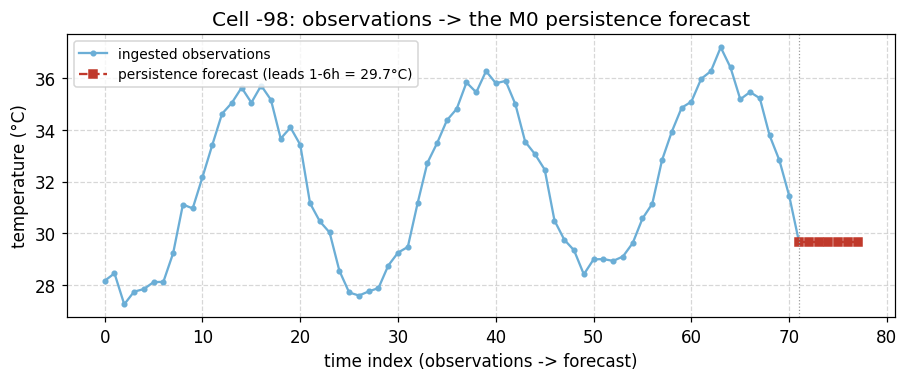

In [22]:

# One grid cell's observed time series plus the persistence forecast (flat over 1..6h).
gid = int(last["grid_id"].iloc[0])
series = obs[obs["grid_id"] == gid].sort_values("tm")
last_ta = float(last[last["grid_id"] == gid]["ta"].iloc[0])
x_obs = np.arange(len(series))
x_pred = np.arange(len(series) - 1, len(series) - 1 + 7)      # continuing from the last observation

fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.plot(x_obs, series["ta"].values, ".-", color="#6baed6", label="ingested observations")
ax.plot(x_pred, [last_ta] * 7, "s--", color="#c0392b", ms=5,
        label=f"persistence forecast (leads 1-6h = {last_ta:.1f}°C)")
ax.axvline(len(series) - 1, color="#999", lw=0.8, ls=":")
ax.set_xlabel("time index (observations -> forecast)"); ax.set_ylabel("temperature (°C)")
ax.set_title(f"Cell {gid}: observations -> the M0 persistence forecast")
ax.grid(True, ls="--", alpha=0.5); ax.legend(loc="best", fontsize=9)
plt.tight_layout()
print(f"cell {gid}: its last observation of {last_ta:.2f}°C is used as the forecast at leads 1-6h.")


> **Observe:** we aligned the observations **ingested today through an OpenAPI** onto the
> Week 4 grid, built the **M0 persistence baseline** from each cell's last value, and passed
> the format validation. In the figure the forecast is a **flat six-hour line** extending from
> the last observation — the simplest possible baseline. This is **M0**, and every model from here
> on has to clear that line. We completed the whole flow
> — **ingest → align → baseline → validate** — in a single notebook.

---
## 🔬 Exercises

The problems below extend today's collector and submission one step at a time.
A working reference solution follows each one, so try it yourself first and then compare.


**Exercise 1 — confirming the server-side filter.** Request only the **first day
(2025-08-01)** of station 133 using `tm1`/`tm2`. How many rows come back (expected: 24)?
Then check that the **row count and temperatures agree** with filtering all 576 rows on the
client, verifying that the server really does filter by `stn` and time.


In [23]:

# Server-side filter: stn=133, one day
srv = requests.get(f"{BASE}/api/obs", params={
    "authKey": MOCK_KEY, "stn": 133,
    "tm1": "202508010000", "tm2": "202508012300",
    "dataType": "JSON", "numOfRows": 100}).json()
srv_df = pd.DataFrame(srv["response"]["body"]["items"]["item"])

# Client-side filter: filtering the full 576 ourselves
cli_df = obs[(obs["stn"] == 133) & (obs["tm"] >= "202508010000")
             & (obs["tm"] <= "202508012300")].sort_values("tm")

print(f"server-side filtered rows: {len(srv_df)}  |  client-side filtered rows: {len(cli_df)}")
diff = float((srv_df["ta"].astype(float).values - cli_df["ta"].values).__abs__().max())
print(f"max absolute temperature difference: {diff:.2e}")
assert len(srv_df) == len(cli_df) == 24 and diff < 1e-9
print("-> the server filters exactly by stn and time (a server-side filter that cuts needless transfer).")


server-side filtered rows: 24  |  client-side filtered rows: 24
max absolute temperature difference: 0.00e+00
-> the server filters exactly by stn and time (a server-side filter that cuts needless transfer).


**Exercise 2 — page size and completeness.** Run `fetch_all` with page sizes 50 and 200.
How does the total page count differ? Check that the **set of collected observations is
completely identical** in both cases (the same 576 `(stn,tm)` pairs) — page size should
change only the *efficiency*, never the *result*.


In [24]:

rows50, tot50, h50 = fetch_all({}, page_size=50, verbose=False)
rows200, tot200, h200 = fetch_all({}, page_size=200, verbose=False)
set50  = {(r["stn"], r["tm"]) for r in rows50}
set200 = {(r["stn"], r["tm"]) for r in rows200}

print(f"page_size=50 : {len(rows50)} rows, {len(h50)} pages (expected ceil(576/50)={math.ceil(576/50)})")
print(f"page_size=200: {len(rows200)} rows, {len(h200)} pages (expected ceil(576/200)={math.ceil(576/200)})")
print(f"the two collections are identical: {set50 == set200 == set(ids)}")
assert set50 == set200 == set(ids)
print("-> page size changes only the number of requests (efficiency); the final collection is the same.")


page_size=50 : 576 rows, 12 pages (expected ceil(576/50)=12)
page_size=200: 576 rows, 3 pages (expected ceil(576/200)=3)
the two collections are identical: True
-> page size changes only the number of requests (efficiency); the final collection is the same.


**Exercise 3 — a climatology variant of M0.** Instead of persistence, build a submission
that uses each grid cell's **overall mean temperature** (climatology) as the 1–6 hour
forecast. Check that it passes the same format validation, and compare how many degrees, on
average, its predictions differ from the persistence submission.


In [25]:

clim = obs.groupby("grid_id", as_index=False)["ta"].mean().rename(columns={"ta": "pred"})
clim_rows = []
for _, r in clim.iterrows():
    for L in range(1, 7):
        clim_rows.append({"id": f"{int(r['grid_id'])}_{L}", "temp": round(float(r["pred"]), 2)})
sub_clim = pd.DataFrame(clim_rows).sort_values("id").reset_index(drop=True)
clim_path = os.path.join(WORK, "submission_M0_clim.csv")
sub_clim.to_csv(clim_path, index=False)

probs = validate_submission(clim_path, n_grid)
print("climatology submission format check:", "passed ✅" if not probs else probs)

m = submission.rename(columns={"temp": "persist"}).merge(
    sub_clim.rename(columns={"temp": "clim"}), on="id")
print(f"mean absolute difference, persistence vs climatology: {(m['persist']-m['clim']).abs().mean():.2f} °C")
print("-> same format, different predictions (last observation vs overall mean). As in Week 4,")
print("  temporal autocorrelation usually puts persistence ahead when verified against later observations.")


climatology submission format check: passed ✅
mean absolute difference, persistence vs climatology: 1.80 °C
-> same format, different predictions (last observation vs overall mean). As in Week 4,
  temporal autocorrelation usually puts persistence ahead when verified against later observations.


---
## Summary

Today we built the closed-loop twin pipeline's **very first piece, ① observation
ingestion**, end to end. For reproducibility we started a **local mock API** imitating the
KMA OpenAPI and learned real HTTP ingestion on top of it:

- **Anatomy of a request:** an OpenAPI = base URL + query parameters + authentication key.
  `requests` assembles the parameters into a URL.
- **Status code vs resultCode:** even with HTTP 200 the body's `resultCode` may signal an
  error — check **both**.
- **Parsing:** JSON, XML and CSV are different serialisations of the same data — we
  confirmed the parsed results agree to within $10^{-9}$.
- **Pagination:** walking `pageNo` up to `totalCount` collected all 576 rows **with no
  duplicates and no gaps** (⌈576/100⌉=6 pages).
- **Reproducibility:** cache + SHA-256 checksum + manifest proved "same request → same data"
  (the second call came from the cache, with no network).
- **Isolation:** the real KMA call lives inside a `KMA_API_KEY` guard — a key-less build
  stays green.
- **The M0 baseline:** ingested observations → grid alignment → persistence baseline →
  format validation.

> **Where are we in the pipeline?** Week 4 **aligned (②)** observations onto a grid; today we
> built the reproducible entrance that **ingests (①)** those observations in the first place,
> and built an **M0 baseline** from them. Stages ① and ② of the pipeline are now
> joined up. Next we put these observations into a **scientific data format (NetCDF, Zarr,
> Xarray — Week 6)** to make a spatiotemporal Dataset, and in Week 8's M1
> (observation-driven ML) we **beat** this M0 for the first time.

### Further Exercises

1. Why is it dangerous to include `authKey` in `fetch_reproducible`'s cache key? (Hint: a
   changed key splits the cache for identical data. And the key leaks into the manifest.)
2. Add `resultCode='03'` (NODATA_ERROR, an empty result) to the mock server, and make the
   collector treat it as an "empty but normal response" rather than a "failure".
3. Using `requests.Session` reuses the connection and speeds up many-page requests. Rewrite
   `fetch_all` on top of a Session and compare the request times.
4. Use the manifest to implement **incremental ingestion**: skip (stn, date) pairs already
   cached and fetch only new dates. How do you get reproducibility and efficiency at once?
5. Obtain a real data.go.kr key, set it as `KMA_API_KEY`, call `getUltraSrtNcst` for a few
   `nx`/`ny` cells, and compare its structure (long format: one row per `category`) with
   today's mock data (wide format: one row per observation).

---
Finally we tidy up the mock server (releasing its resources).

In [83]:

httpd.shutdown()
print("mock weather API stopped. Today's outputs:")
print("  · the reproducible ingestion manifest ->", os.path.join(WORK, "ingest_manifest.json"))
print("  · the M0 persistence submission       ->", os.path.join(WORK, "submission_M0.csv"))
print("Well done -- Week 6 continues with NetCDF, Zarr and Xarray.")


mock weather API stopped. Today's outputs:
  · the reproducible ingestion manifest -> /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk05_xl55s07e/ingest_manifest.json
  · the M0 persistence submission       -> /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk05_xl55s07e/submission_M0.csv
Well done -- Week 6 continues with NetCDF, Zarr and Xarray.
